# CMSC320 Programming Assignment 4
Please go through the file following the instructions as you go.

Rename this notebook to `CMSC320_PA4_YourName.ipynb`


# EDA/Data Visualization and Hypothesis Testing


In this assignment, we will go back to PA2 data `PA2_student_study_data.csv` (same name as before), explore and visualize it and run a Hypothesis Test.

In [1]:
#run this cell
import pandas as pd

Run the cell below and upload the .csv file to the Colab cloud so you can use it.



In [ ]:
# from google.colab import files


# uploaded = files.upload()

# using VSCODE not colab!!! (NOTE)

Run the cell below to load the data from .csv and preview it.

In [4]:
df = pd.read_csv("PA2_student_study_data copy.csv")
df.head()

,student_id,group,age,gender,study_hours,score
0,1,Control,39,Female,8.0,73.1
1,2,Treatment,34,Female,5.1,63.7
2,3,Treatment,26,Female,10.5,74.0
3,4,Treatment,18,Female,13.9,73.8
4,5,Control,38,Female,8.6,80.7


For all the questions below, feel free to look up functions in our slides or online.

Also feel free to create additional code cells to print multiple things (remember that without `print()` you can only print one thing per cell) but please make a comment (`#`) at the top of each new code cell to describe what it does.

## Part 1: Exploratory Data Analysis

**For each plot, make a title.**

Here we'll run commands and make visualizations to learn more about this data. Note that you can consult PA2 on hints for what this data is.

Note that all the operations we performed on this data in PA2 were EDA too.

In [5]:
#run this cell
import matplotlib.pyplot as plt

In [6]:
#run this cell
df.describe()

,student_id,age,study_hours,score
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,28.340000,10.924800,82.045800
std,144.481833,6.512544,3.274531,8.003787
min,1.000000,18.000000,1.800000,57.500000
25%,125.750000,22.750000,8.775000,76.700000
50%,250.500000,28.000000,10.900000,82.400000
75%,375.250000,34.000000,13.100000,87.100000
max,500.000000,39.000000,21.400000,105.100000


**1 (2 pts).** The above cell only describes the numerical columns. Find a way to use describe on the categorical columns (which are those?) and run it in the cell below. Feel free to make additional cells if needed.

In [9]:
#1 

df.describe(include=['object'])

,group,gender
count,500,500
unique,2,3
top,Treatment,Female
freq,259,247


**2 (2 pts).** Make a histogram of age. Look for an optimal number of bins that seems to capute the variability of the data without making the histogram too complex.

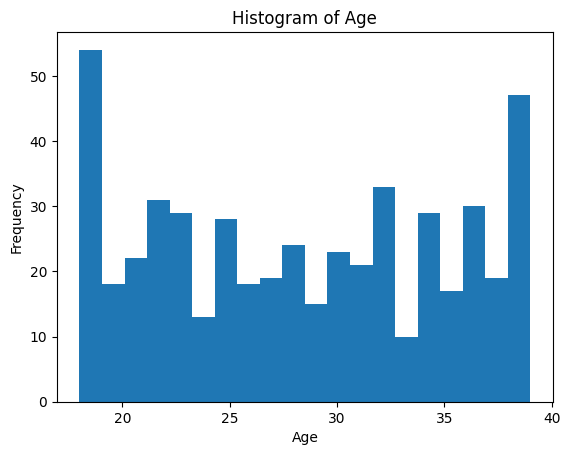

In [19]:
#2

plt.hist(df['age'], bins=20)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**3 (2 pts).** Make a bar chart of gender.

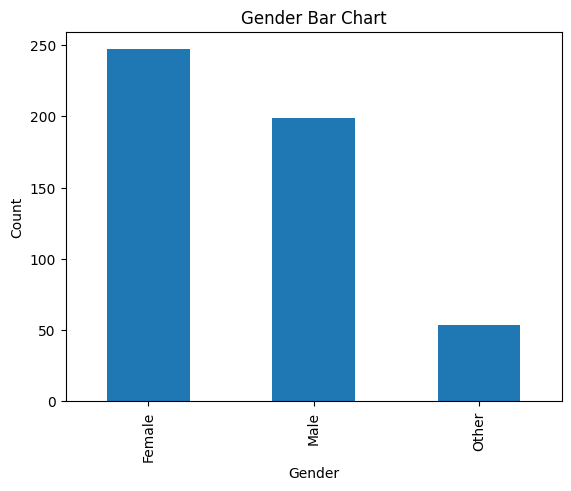

In [21]:
#3

df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Bar Chart")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


**4 (4 pts).** Make a stacked bar chart of group and gender. Group should be the main distinction, and then each group bar should be broken down into "male", "female" and "other" subcategories. Make sure it's clear on the plot what subcategory each color represents.

Example where groups are sports, and each column has gender subcategories like what we're looking for (except we have 3 categories for gender): [link](https://www.statology.org/wp-content/uploads/2021/10/stack6.png).

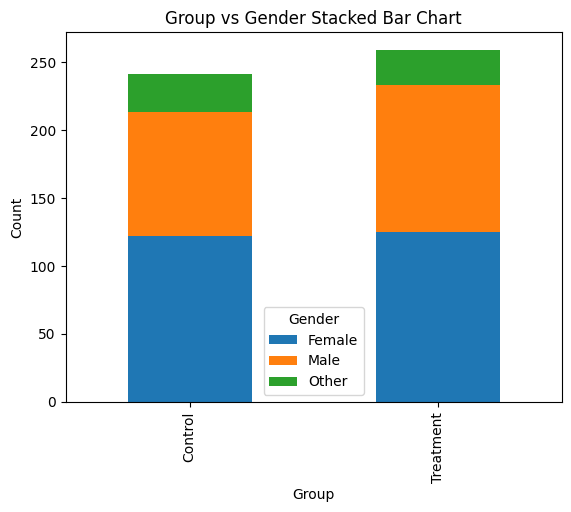

In [ ]:
#4

cross_tabulation = pd.crosstab(df['group'], df['gender'])

cross_tabulation.plot(kind='bar', stacked=True)
plt.title("Group vs Gender Stacked Bar Chart")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="Gender") # show each group bar browkn down into male, female, other
plt.show()

**5 (1 pt).** Make a histogram of study_hours. Look for an optimal number of bins that seems to capute the variability of the data without making the histogram too complex.

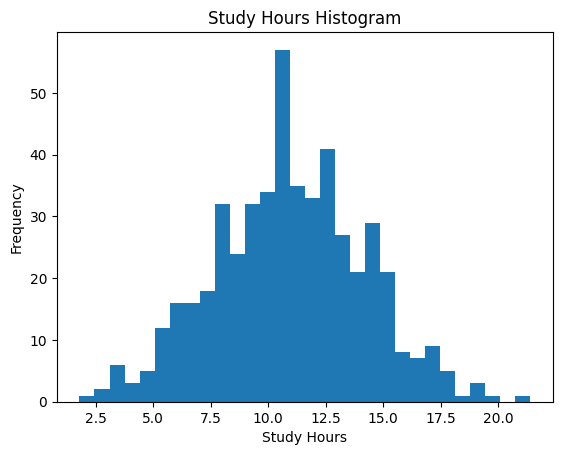

In [30]:
#5

plt.hist(df['study_hours'], bins=30)
plt.title("Study Hours Histogram")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

**6 (1 pt).** Make a histogram of score. Look for an optimal number of bins that seems to capute the variability of the data without making the histogram too complex.

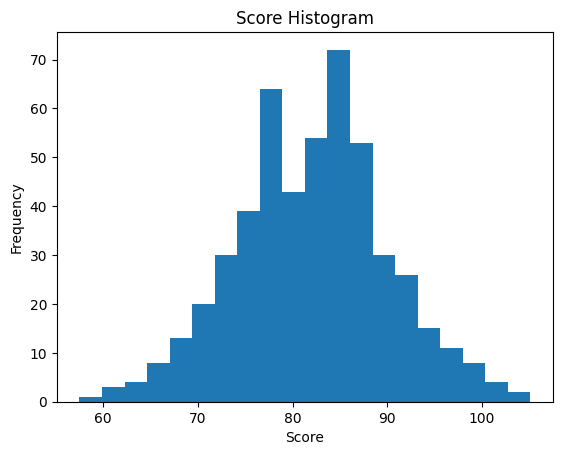

In [34]:
#6

plt.hist(df['score'], bins=20)
plt.title("Score Histogram")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


**7 (4 pts).** Make a histogram of score for Female rows. Make a histogram of score for Male rows. Display both histograms directly on top of one another.

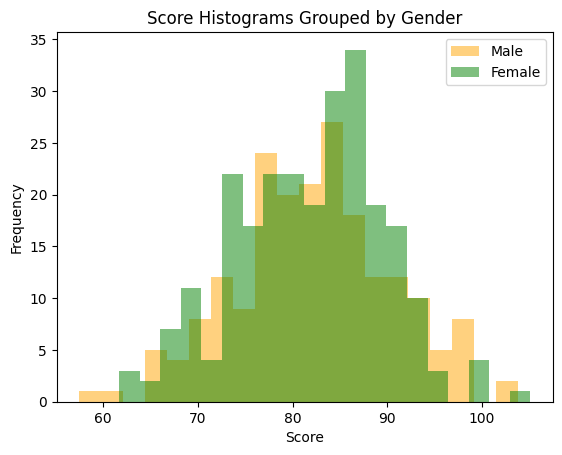

In [37]:
#7
#feel free to make additional cells here and in the other questions

male = df[df['gender'] == 'Male']['score'] # male rows score
female = df[df['gender'] == 'Female']['score'] # female rows score

plt.hist(male, bins=20, alpha=0.5, label='Male', color = 'orange')
plt.hist(female, bins=20, alpha=0.5, label='Female', color = 'green')
# placed them overlapping with alpha opacity at 0.5 to make the colors see-through

plt.title("Score Histograms Grouped by Gender")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**8 (2 pt).** Make a histogram of score for Control rows. Make a histogram of score for Treatment rows. Display both histograms directly on top of one another.

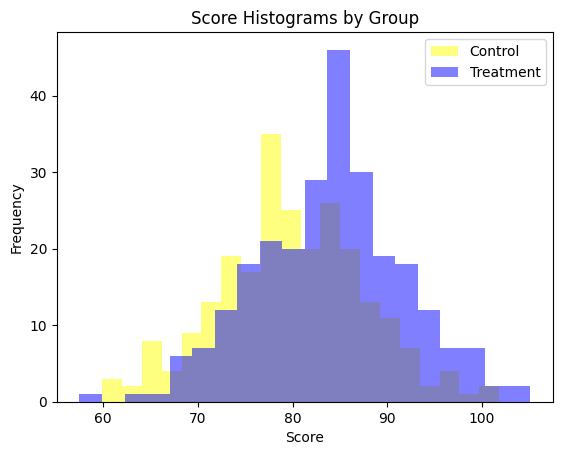

In [49]:
#8

control = df[df['group'] == 'Control']['score'] # control rows
treatment = df[df['group'] == 'Treatment']['score'] # treatment rows

plt.hist(control, bins=20, alpha=0.5, label='Control', color = 'yellow') 
plt.hist(treatment, bins=20, alpha=0.5, label='Treatment', color = 'blue')
# placed overlapping on one another with color opacity set to 0.5 to make them partially see through

plt.title("Score Histograms by Group")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


We mentioned that the data is about a program designed to increase scores.

**9 (2 pts).**

**Share your observations from the above plot here:**

**10 (4 pts).** Copy your code for the previous histogram into the cell below and find a way to plot a vertical line for the mean of each of the 2 histograms.

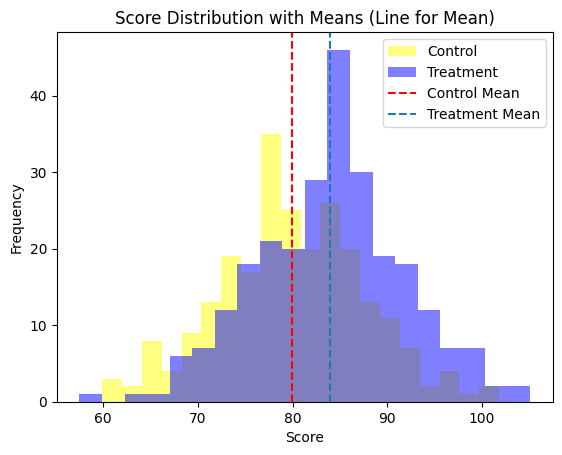

In [50]:
#10

import numpy as np

plt.hist(control, bins=20, alpha=0.5, label='Control', color = 'yellow') # control rows
plt.hist(treatment, bins=20, alpha=0.5, label='Treatment', color = 'blue') # treatment rows

# placed overlapping on one another with color opacity set to 0.5 to make them partially see through

plt.axvline(np.mean(control), linestyle='dashed', label='Control Mean', color = 'red') # control mean line 
plt.axvline(np.mean(treatment), linestyle='dashed', label='Treatment Mean') # treatment mean vertical line

plt.title("Score Distribution with Means (Line for Mean)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


**11 (2 pts).** What's a good way to relate study hours and score in a plot? Make that plot and label both axes.

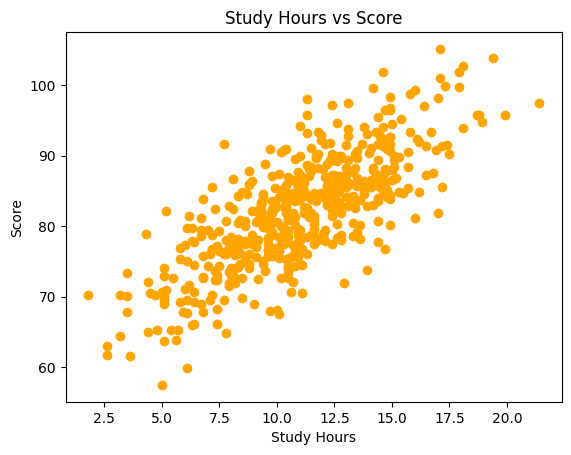

In [44]:
#11

plt.scatter(df['study_hours'], df['score'], color = 'orange')
plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

**12 (2 pts).**

**Share your observations from the above plot here:**

There is a strong positive correlation (r coefficient)between study hours and score given the scatterplot above. If I were to plot a line of best fit, the majority of the data points would be consolidated around the line in most areas (Strong linearity). 

**13 (2 pts).** Make the same kind of plot as in the previous question, but add GROUP data by coloring Control data red and Treatment data green.

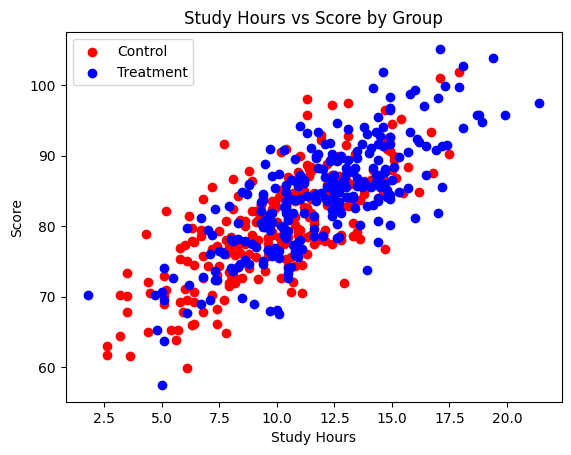

In [ ]:
#13

control = df[df['group'] == 'Control'] # control cluster
treatment = df[df['group'] == 'Treatment'] # treatment cluster

plt.scatter(control['study_hours'], control['score'], label='Control', color = 'red')
plt.scatter(treatment['study_hours'], treatment['score'], label='Treatment', color = 'blue')
# red dot control group, and blue dot treatment group with data from these points included and labeled in the legend/df

plt.title("Study Hours vs Score by Group")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.show()

**14 (2 pts).** How does adding group information inform your understanding of whether the Treatment was successful ahead of the Hypothesis test? Importantly, does the histogram in **Question 10** OR this plot give you more of a sense of the Treatment's effect?

**Share your observations here:**

The group information included in this version of the scatterplot appears to have a lot of treatment points cluster around higher overall scores for the same study hour distribution than the control group points, revealing that those in the treatment group of this data are getting better scores on average. This same sentiment is shared by the histograms in question 10, as the treatment histogram and its mean axis line are shifted to the right of the control group, showcasing an increase.

**15 (2 pts).** Create a 2x2 table that plots the mean score and the mean study_hours for each of the 2 groups.

In [51]:
#15

df.groupby('group')[['score', 'study_hours']].mean()

,score,study_hours
group,,
Control,79.982573,9.947303
Treatment,83.965637,11.834363


**16 (2 pts).** How do the histogram (Q10), the plot (Q13) and the table (Q15) aid your understanding of the efficiency of the Treament? Which one is better at what?

**Share your observations here:**

The inclusion of all three methods of analyzing the metrics between the treatment and control groups of this distribution of data allow us to confirm the validity of each of them, since we see that all of them show the same trend. The histogram and the scatterplot give us a narrative breakdown for slight distribution differences and separation respectively, while the table gives actual numerical comparisons between the two. In the end, by looking at the distinct details and subtle nuance, they all tell the same breakdown in a different way. 

## Part 2: Hypothesis Testing

Here, we will look at whether the difference in the mean score by group and the difference in the mean study_hours by group is statistically significant.

How do we know if the difference is significant?

We will use a **t-test** to check whether the mean score in the Treatment group is higher than in the Control group.

- Null hypothesis ($H_0$): There is no significant difference in mean scores between groups.  
- Alternative hypothesis ($H_1$): The Treatment group has a statistically significantly higher mean score.  

In [53]:
#run this cell
from scipy import stats

In [54]:
#run this cell
#read through the code to understand what it does
control_scores = df[df["group"] == "Control"]["score"]
control_scores.head()
#this is a list of scores for people in the Control group

0     73.1
4     80.7
5     87.9
6     94.5
10    73.5
Name: score, dtype: float64

In [55]:
#run this cell
#read through the code to understand what it does
treatment_scores = df[df["group"] == "Treatment"]["score"]
treatment_scores.head()
#this is a list of scores for people in the Treatment group

1    63.7
2    74.0
3    73.8
7    98.7
8    85.9
Name: score, dtype: float64

In [56]:
#run this cell
#read through the code to understand what it does
t_stat, p_val = stats.ttest_ind(treatment_scores, control_scores, alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: 5.735195560344067
p-value: 8.457121976226528e-09


**1 (1 pt).** What is the p-value?

**Answer here:** 8.46



**2 (1 pt).** If we use a significance level of 0.05, do we reject the null hypothesis?

**Answer here:** Yes, the p-value of 8.46 x 10^-9 is very small and leads us to reject the null hypothesis since 8.46 x 10^-9 < 0.05.

**3 (2 pts).** What does this mean in the context of the study program (i.e. what policy recommendation may we give)?

**Answer here:** This means there is statistically significant evidence that the treatment increases student scores, as the rejection of the null hypothesis that there is no statistically significant difference in the mean scores between two groups makes the study program given quite effective for future reccomendations. 

Now we want to test whether the mean study_hours differ significantly by group

**4 (2 pts).** What are the hypotheses?

We will use a **t-test** to check whether the mean study_hours in the Treatment group is higher than in the Control group.

- Null hypothesis ($H_0$): There is no significant difference between mean study hours for the two groups
- Alternative hypothesis ($H_1$): The treatment group has statistically significantly higher mean study hours.

**5 (2 pts).** In the cell below, run commands similar to what we did above and calculate the p-value for this test.

In [57]:
#5

control_hours = df[df['group'] == 'Control']['study_hours']
treatment_hours = df[df['group'] == 'Treatment']['study_hours']

t_stat, p_val = stats.ttest_ind(treatment_hours, control_hours, alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: 6.717532849033697
p-value: 2.5305637226701668e-11


**6 (2 pts).** Would you reject the null at alpha=0.01? Justify

Yes, as the p-value of 2.53 x 10^-11 is much lower than the alpha level of 0.01, leading us to reject the null hypothesis. 

**7 (2 pt).** Was this a one-sided test or a two-sided test? Justify.

This was a one-sided test since we are testing whether the treatment mean itself is greater than the control mean. It would be two-sided if we happened to be detecting an equality difference instead. 


**8 (2 pt).** Was this a one-sample test or a two-sample test? Justify.

This was a two-sample test because we are comparing two independent groups control and treatment. The individuals apart of both make up two different samples. 

## Part 3: Submitting your work

### Congrats on finishing PA4!

1. Save this notebook (`File > Save`).
2. Download it to your computer as `.ipynb` (`File > Download > Download .ipynb`).
3. Submit the .ipynb file on Canvas.

Tips:
1. After finishing the work, click on the arrow to the right of "Run all" and then click on "Clear all outputs" and "Restart session." Then run each cell in order to make sure everything compiles.
2. Remember to delete the cells you created for testing and any Gemini-affected cells if you used help from Gemini.

